<a href="https://colab.research.google.com/github/icmsol/capstone-project-4-deep-learning-systems/blob/main/deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transformer-Based Classification of Contract Clause Themes

**Capstone Project 4 — Deep Learning Systems**

This notebook implements a PyTorch Transformer experiment using the Contract Understanding Atticus Dataset (CUAD). The project adapts expert-annotated contract passages into a ten-class text-classification task that demonstrates a foundation for ICM Solutions knowledge reuse and document-quality workflows.

## Phase 4 setup objective

This initial version validates the Google Colab environment, GPU availability, repository data access, and dataset integrity. Model implementation and training sections will be added after the environment is confirmed.

## 1. Environment and library validation

The notebook uses standard Python data-science and PyTorch libraries required by the project rubric.

In [7]:
import os
import platform
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

try:
    import sklearn
    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
    SKLEARN_VERSION = sklearn.__version__
except ImportError as exc:
    raise ImportError("scikit-learn is required for evaluation metrics.") from exc

print(f"Python: {platform.python_version()}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"PyTorch: {torch.__version__}")
print(f"scikit-learn: {SKLEARN_VERSION}")

Python: 3.12.13
NumPy: 2.0.2
Pandas: 2.2.2
PyTorch: 2.11.0+cu128
scikit-learn: 1.6.1


## 2. Reproducibility settings

A fixed seed is applied to Python, NumPy, and PyTorch. GPU operations can still show small numerical differences across hardware and runtime versions.

In [8]:
SEED = 42

def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

set_seed()
print(f"Random seed set to {SEED}.")

Random seed set to 42.


## 3. Device validation

Google Colab should be configured to use a GPU runtime. CUDA is preferred, but the notebook retains a CPU fallback.

In [9]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Selected device: {DEVICE}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version reported by PyTorch: {torch.version.cuda}")
    total_memory_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    print(f"GPU memory: {total_memory_gb:.2f} GB")
else:
    print("CUDA is not available. In Colab, select Runtime > Change runtime type > GPU.")

Selected device: cuda
GPU: Tesla T4
CUDA version reported by PyTorch: 12.8
GPU memory: 14.56 GB


## 4. Load the processed CUAD classification dataset

The processed dataset is stored in the public GitHub repository. Loading it from the raw GitHub URL makes the notebook portable across Colab and local environments without requiring a hard-coded personal path.

In [10]:
REPOSITORY = "icmsol/capstone-project-4-deep-learning-systems"
DATA_URL = (
    "https://raw.githubusercontent.com/"
    f"{REPOSITORY}/main/data/processed/cuad_clause_classification.csv"
)

required_columns = {
    "example_id",
    "contract_id",
    "category",
    "label_id",
    "clause_text",
    "word_count",
    "char_count",
    "fold",
    "split",
}

df = pd.read_csv(DATA_URL)

missing_columns = required_columns.difference(df.columns)
if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {sorted(missing_columns)}")

print(f"Loaded dataset from: {DATA_URL}")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
display(df.head(3))

Loaded dataset from: https://raw.githubusercontent.com/icmsol/capstone-project-4-deep-learning-systems/main/data/processed/cuad_clause_classification.csv
Rows: 4,356
Columns: 10


,example_id,contract_id,category,label_id,clause_text,normalized_text_sha256,word_count,char_count,fold,split
0,cuad_00001,2ThemartComInc_19990826_10-12G_EX-10.10_670028...,Anti-Assignment,1,All rights (under any applicable intellectual ...,af891b98e116865ceedb3dd7b9d507a112e035bdcebf17...,15,136,0,train
1,cuad_00002,2ThemartComInc_19990826_10-12G_EX-10.10_670028...,Audit Rights,0,Any such inspection will be conducted in a man...,b5eacc8b554017a31e706c6b76157368f8316ba1a83b34...,27,170,0,train
2,cuad_00003,2ThemartComInc_19990826_10-12G_EX-10.10_670028...,Audit Rights,0,"Once every twelve (12) months, 2TheMart throug...",20f2ee68166411158e23c938ca5ee88c446d34d62cc77d...,18,107,0,train


## 5. Dataset integrity checks

The split is grouped by source contract. These checks verify that no contract appears in more than one of the training, validation, or test partitions.

In [11]:
expected_splits = {"train", "validation", "test"}
observed_splits = set(df["split"].unique())

if observed_splits != expected_splits:
    raise ValueError(
        f"Expected splits {sorted(expected_splits)}, but found {sorted(observed_splits)}."
    )

split_summary = (
    df.groupby("split")
      .agg(
          passages=("example_id", "count"),
          contracts=("contract_id", "nunique"),
          categories=("category", "nunique"),
      )
      .reindex(["train", "validation", "test"])
)

train_contracts = set(df.loc[df["split"] == "train", "contract_id"])
validation_contracts = set(df.loc[df["split"] == "validation", "contract_id"])
test_contracts = set(df.loc[df["split"] == "test", "contract_id"])

overlap_checks = {
    "train_validation_overlap": len(train_contracts & validation_contracts),
    "train_test_overlap": len(train_contracts & test_contracts),
    "validation_test_overlap": len(validation_contracts & test_contracts),
}

if any(overlap_checks.values()):
    raise ValueError(f"Contract leakage detected: {overlap_checks}")

print("Split summary:")
display(split_summary)
print("Contract overlap checks:", overlap_checks)
print("Dataset integrity checks passed.")

Split summary:


,passages,contracts,categories
split,,,
train,3486,368,10
validation,435,48,10
test,435,46,10


Contract overlap checks: {'train_validation_overlap': 0, 'train_test_overlap': 0, 'validation_test_overlap': 0}
Dataset integrity checks passed.


## 6. Preliminary class and length inspection

These outputs confirm that all ten selected categories are present and provide an initial view of text-length variability.

,label_id,category,passages,contracts,median_words,max_words
0,0,Audit Rights,605,213,42.0,344
1,1,Anti-Assignment,556,354,36.0,704
2,2,Insurance,521,166,39.0,350
3,3,Cap On Liability,505,227,48.0,299
4,4,Governing Law,442,422,29.0,141
5,5,Revenue/Profit Sharing,381,161,46.0,335
6,6,Minimum Commitment,363,156,45.0,331
7,7,Post-Termination Services,361,174,60.0,372
8,8,License Grant,351,181,50.0,462
9,9,Ip Ownership Assignment,271,114,54.0,473


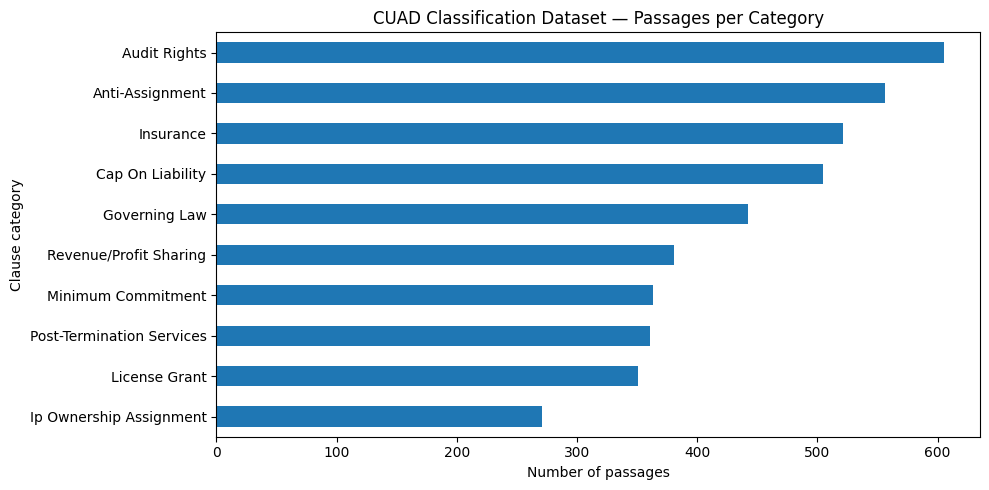

In [12]:
category_summary = (
    df.groupby(["label_id", "category"])
      .agg(
          passages=("example_id", "count"),
          contracts=("contract_id", "nunique"),
          median_words=("word_count", "median"),
          max_words=("word_count", "max"),
      )
      .reset_index()
      .sort_values("label_id")
)

display(category_summary)

fig, ax = plt.subplots(figsize=(10, 5))
category_counts = df["category"].value_counts().sort_values()
category_counts.plot(kind="barh", ax=ax)
ax.set_title("CUAD Classification Dataset — Passages per Category")
ax.set_xlabel("Number of passages")
ax.set_ylabel("Clause category")
plt.tight_layout()
plt.show()

## Phase 4 completion

The Google Colab environment, T4 GPU availability, repository data access, and contract-level split integrity were successfully validated. The following Phase 5 sections document the dataset source, adaptation method, structural audit, selected clause categories, representative records, length considerations, and split balance.

# Phase 5 — CUAD Source, Structure, and Data-Quality Audit

This section documents the provenance and structure of the Contract Understanding Atticus Dataset (CUAD), explains how the original clause-extraction annotations were adapted into a single-label classification dataset, and validates the processed records before model preprocessing begins.

The original CUAD v1 release contains 510 commercial contracts and more than 13,000 expert-supervised annotations across 41 clause categories. This project uses the official `master_clauses.csv` source and a reproducible preprocessing script stored in the repository. CUAD remains licensed separately from this project's code under the Creative Commons Attribution 4.0 International license.

**Official sources**

- Dataset overview: https://www.atticusprojectai.org/cuad/
- Archived release and DOI: https://doi.org/10.5281/zenodo.4595826
- Official repository: https://github.com/TheAtticusProject/cuad
- Dataset paper: *CUAD: An Expert-Annotated NLP Dataset for Legal Contract Review* (NeurIPS 2021)

The source benchmark was designed to locate legally significant passages within contracts. For this capstone, the expert-annotated answer passages are transparently adapted into a ten-class clause-theme classification task. The model therefore classifies passages that have already been identified as relevant; it does not perform complete autonomous contract review or provide legal advice.

## 7. Load the formal audit artifacts

The audit files were generated by the reproducible `src/prepare_cuad_classification.py` script and committed with the processed dataset. They record source dimensions, cleaning rules, category-selection logic, and split distributions.

In [13]:
import json
from urllib.request import urlopen

AUDIT_BASE_URL = (
    "https://raw.githubusercontent.com/"
    f"{REPOSITORY}/main/data/audit"
)

AUDIT_SUMMARY_URL = f"{AUDIT_BASE_URL}/cuad_data_audit_summary.json"
CATEGORY_AUDIT_URL = f"{AUDIT_BASE_URL}/cuad_selected_category_audit.csv"
SPLIT_DISTRIBUTION_URL = f"{AUDIT_BASE_URL}/cuad_split_distribution.csv"

with urlopen(AUDIT_SUMMARY_URL) as response:
    audit_summary = json.load(response)

category_audit = pd.read_csv(CATEGORY_AUDIT_URL)
split_distribution_audit = pd.read_csv(SPLIT_DISTRIBUTION_URL)

source_summary = pd.DataFrame(
    {
        "Measure": [
            "Source contracts",
            "Source columns",
            "Clause categories",
            "Raw annotated passages",
            "Clean unique passages across all 41 categories",
            "Final classification passages",
            "Final source contracts",
            "Final classes",
        ],
        "Value": [
            audit_summary["source"]["source_rows_contracts"],
            audit_summary["source"]["source_columns"],
            audit_summary["source"]["context_category_columns"],
            audit_summary["raw_audit"]["raw_context_annotations"],
            audit_summary["raw_audit"]["clean_unique_category_passages_all_41_categories"],
            audit_summary["final_dataset"]["examples"],
            audit_summary["final_dataset"]["distinct_contracts"],
            audit_summary["final_dataset"]["classes"],
        ],
    }
)

display(source_summary)
print(f"CUAD DOI: {audit_summary['source']['official_dataset_doi']}")
print(f"CUAD license: {audit_summary['source']['official_license']}")

,Measure,Value
0,Source contracts,510
1,Source columns,83
2,Clause categories,41
3,Raw annotated passages,13101
4,Clean unique passages across all 41 categories,9981
5,Final classification passages,4356
6,Final source contracts,462
7,Final classes,10


CUAD DOI: 10.5281/zenodo.4595826
CUAD license: CC BY 4.0


## 8. Adaptation and cleaning rules

The classification table was created using the following fixed rules:

1. Extract each expert-annotated clause passage and retain its source contract identifier and CUAD category.
2. Preserve the original passage for model input; normalize whitespace and letter case only for duplicate and conflict detection.
3. Within a category, retain one deterministic representative of identical normalized text.
4. Remove identical normalized passages assigned to more than one category because this capstone uses a single-label output.
5. Exclude blank or unparsable passages.
6. Exclude five metadata-oriented labels—Document Name, Parties, Agreement Date, Effective Date, and Expiration Date—from theme selection.
7. Require at least 100 distinct source contracts per eligible category.
8. Rank eligible categories by clean unique passage count and select the ten highest-volume categories, with alphabetical order as the tie-breaker.

These rules were fixed before model training and are not based on validation or test performance.

In [14]:
duplicate_audit = pd.DataFrame(
    {
        "Audit measure": [
            "Normalized text values appearing more than once",
            "Rows in any duplicate group",
            "Normalized text values assigned to multiple categories",
            "Rows in multiple-category conflict groups",
            "Clean unique passages remaining across all 41 categories",
        ],
        "Count": [
            audit_summary["raw_audit"]["normalized_text_values_with_any_duplicate"],
            audit_summary["raw_audit"]["rows_in_any_duplicate_group"],
            audit_summary["raw_audit"]["normalized_text_values_with_multiple_categories"],
            audit_summary["raw_audit"]["rows_in_multiple_category_groups"],
            audit_summary["raw_audit"]["clean_unique_category_passages_all_41_categories"],
        ],
    }
)

display(duplicate_audit)

integrity_audit = pd.DataFrame(
    {
        "Check": [
            "Missing values in required fields",
            "Duplicate example IDs",
            "Duplicate normalized-text hashes",
            "Contracts assigned to multiple splits",
            "Unexpected class count",
        ],
        "Result": [
            int(df[list(required_columns)].isna().sum().sum()),
            int(df["example_id"].duplicated().sum()),
            int(df["normalized_text_sha256"].duplicated().sum()),
            int((df.groupby("contract_id")["split"].nunique() > 1).sum()),
            int(df["category"].nunique() != 10),
        ],
    }
)

display(integrity_audit)

if integrity_audit["Result"].sum() != 0:
    raise ValueError("One or more processed-dataset integrity checks failed.")

print("All processed-dataset quality checks passed.")

,Audit measure,Count
0,Normalized text values appearing more than once,1336
1,Rows in any duplicate group,3393
2,Normalized text values assigned to multiple ca...,1063
3,Rows in multiple-category conflict groups,2344
4,Clean unique passages remaining across all 41 ...,9981


,Check,Result
0,Missing values in required fields,0
1,Duplicate example IDs,0
2,Duplicate normalized-text hashes,0
3,Contracts assigned to multiple splits,0
4,Unexpected class count,0


All processed-dataset quality checks passed.


## 9. Selected category audit

The ten selected categories represent substantive contract-review themes and are supported by at least 100 distinct contracts after cleaning. `retained_pct` shows the percentage of raw category annotations retained after duplicate and conflicting-label controls.

,label_id,category,raw_annotations,clean_unique_passages,clean_contracts,retained_pct,train,validation,test
0,0,Audit Rights,613,605,213,98.7%,485,61,59
1,1,Anti-Assignment,612,556,354,90.8%,445,55,56
2,2,Insurance,531,521,166,98.1%,417,52,52
3,3,Cap On Liability,632,505,227,79.9%,404,50,51
4,4,Governing Law,457,442,422,96.7%,353,45,44
5,5,Revenue/Profit Sharing,395,381,161,96.5%,305,38,38
6,6,Minimum Commitment,392,363,156,92.6%,291,36,36
7,7,Post-Termination Services,409,361,174,88.3%,288,36,37
8,8,License Grant,716,351,181,49.0%,281,35,35
9,9,Ip Ownership Assignment,296,271,114,91.6%,217,27,27


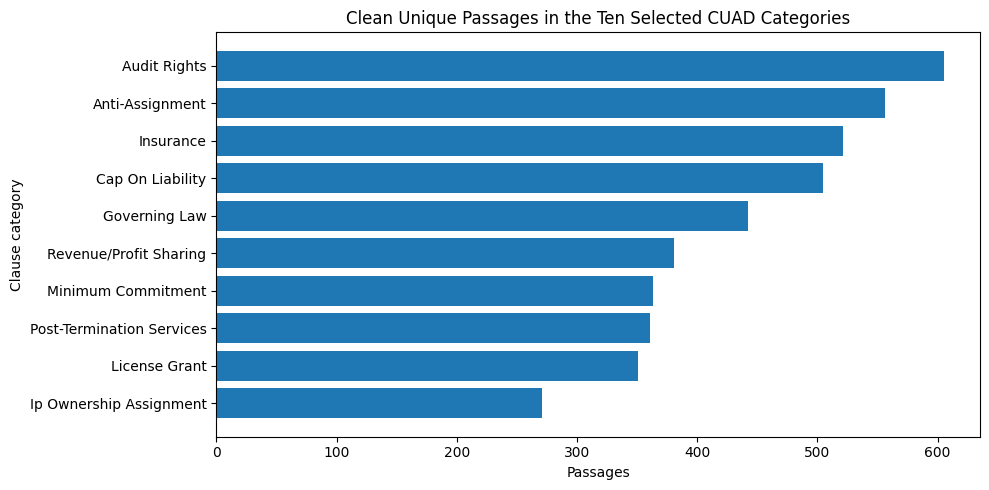

In [15]:
selected_category_table = (
    category_audit[
        [
            "label_id",
            "category",
            "raw_annotations",
            "clean_unique_passages",
            "clean_contracts",
            "retained_pct",
            "train",
            "validation",
            "test",
        ]
    ]
    .sort_values("label_id")
    .reset_index(drop=True)
)

display(
    selected_category_table.style.format(
        {
            "retained_pct": "{:.1f}%",
        }
    )
)

fig, ax = plt.subplots(figsize=(10, 5))
plot_data = selected_category_table.sort_values("clean_unique_passages")
ax.barh(plot_data["category"], plot_data["clean_unique_passages"])
ax.set_title("Clean Unique Passages in the Ten Selected CUAD Categories")
ax.set_xlabel("Passages")
ax.set_ylabel("Clause category")
plt.tight_layout()
plt.show()

## 10. Representative clause passages

A representative passage near the median word count is displayed for each category. These examples help verify that the inputs contain meaningful clause language rather than category names, filenames, or document metadata.

In [16]:
def select_near_median(group: pd.DataFrame) -> pd.Series:
    median_words = group["word_count"].median()
    selected_index = (group["word_count"] - median_words).abs().idxmin()
    return group.loc[selected_index]

representative_samples = (
    df.groupby(["label_id", "category"], group_keys=False)
      .apply(select_near_median, include_groups=False)
      .reset_index()
      .sort_values("label_id")
)

representative_samples["clause_excerpt"] = (
    representative_samples["clause_text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.slice(0, 320)
)

display(
    representative_samples[
        ["label_id", "category", "split", "word_count", "clause_excerpt"]
    ].reset_index(drop=True)
)

,label_id,category,split,word_count,clause_excerpt
0,0,Audit Rights,validation,42,"Company shall have the right, under EUR OPS or..."
1,1,Anti-Assignment,train,36,This Agreement and all rights and duties hereu...
2,2,Insurance,validation,39,In respect of Hull and Spares All Risk Insuran...
3,3,Cap On Liability,train,48,Neither party shall be liable to the other par...
4,4,Governing Law,test,29,This Development Agreement shall be governed b...
5,5,Revenue/Profit Sharing,train,46,All payments shall be made by wire transfer dr...
6,6,Minimum Commitment,train,45,"With respect to each Contract Year, by no late..."
7,7,Post-Termination Services,train,60,"However, the Parties agree that the RemainCo G..."
8,8,License Grant,train,50,"Fox also grants Licensee a limited, non-exclus..."
9,9,Ip Ownership Assignment,train,54,Consultant also hereby irrevocably transfers a...


## 11. Clause-length and truncation considerations

The design uses a maximum sequence length of 256 model tokens. The source table currently records whitespace-delimited word counts, which serve only as a preliminary length proxy. Exact token lengths and actual truncation rates will be recalculated after the training-only vocabulary and tokenizer are built in Phase 7.

,quantile,word_count
0,0.00,2.00
1,0.25,28.00
2,0.50,43.00
3,0.75,67.00
4,0.90,100.00
5,0.95,136.00
6,0.99,238.45
7,1.00,704.00


Passages exceeding 256 whitespace-delimited words: 36 (0.83%)


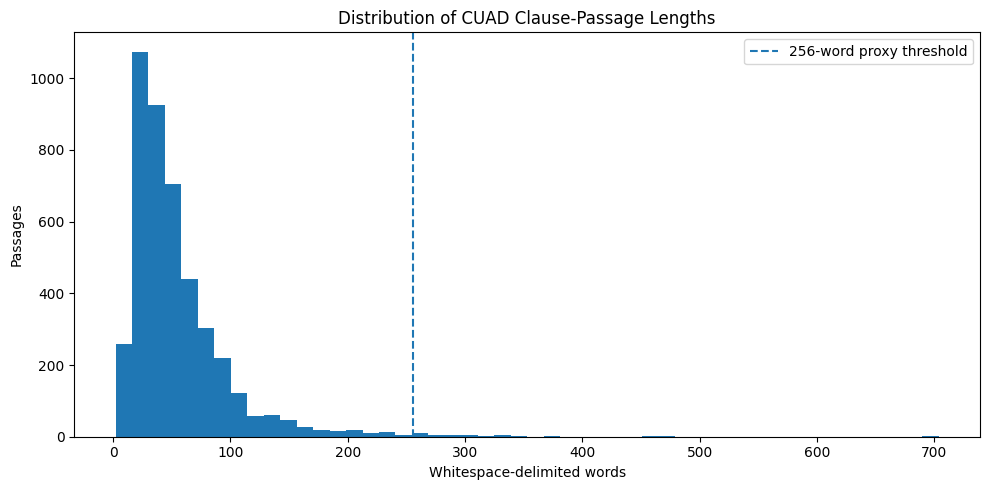

In [17]:
length_quantiles = (
    df["word_count"]
      .quantile([0.00, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 1.00])
      .rename_axis("quantile")
      .reset_index(name="word_count")
)

display(length_quantiles)

word_proxy_over_limit = int((df["word_count"] > 256).sum())
word_proxy_over_limit_pct = 100 * word_proxy_over_limit / len(df)

print(
    f"Passages exceeding 256 whitespace-delimited words: "
    f"{word_proxy_over_limit:,} ({word_proxy_over_limit_pct:.2f}%)"
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df["word_count"], bins=50)
ax.axvline(256, linestyle="--", label="256-word proxy threshold")
ax.set_title("Distribution of CUAD Clause-Passage Lengths")
ax.set_xlabel("Whitespace-delimited words")
ax.set_ylabel("Passages")
ax.legend()
plt.tight_layout()
plt.show()

## 12. Contract-grouped split balance

The processed dataset uses contract-level groups, so all passages from a source contract remain in one partition. This is more conservative than randomly splitting individual passages because similar language from the same contract cannot leak across training, validation, and test data.

split,train,validation,test
category,,,
Anti-Assignment,445,55,56
Audit Rights,485,61,59
Cap On Liability,404,50,51
Governing Law,353,45,44
Insurance,417,52,52
Ip Ownership Assignment,217,27,27
License Grant,281,35,35
Minimum Commitment,291,36,36
Post-Termination Services,288,36,37


split,train,validation,test
category,,,
Anti-Assignment,80.0%,9.9%,10.1%
Audit Rights,80.2%,10.1%,9.8%
Cap On Liability,80.0%,9.9%,10.1%
Governing Law,79.9%,10.2%,10.0%
Insurance,80.0%,10.0%,10.0%
Ip Ownership Assignment,80.1%,10.0%,10.0%
License Grant,80.1%,10.0%,10.0%
Minimum Commitment,80.2%,9.9%,9.9%
Post-Termination Services,79.8%,10.0%,10.2%


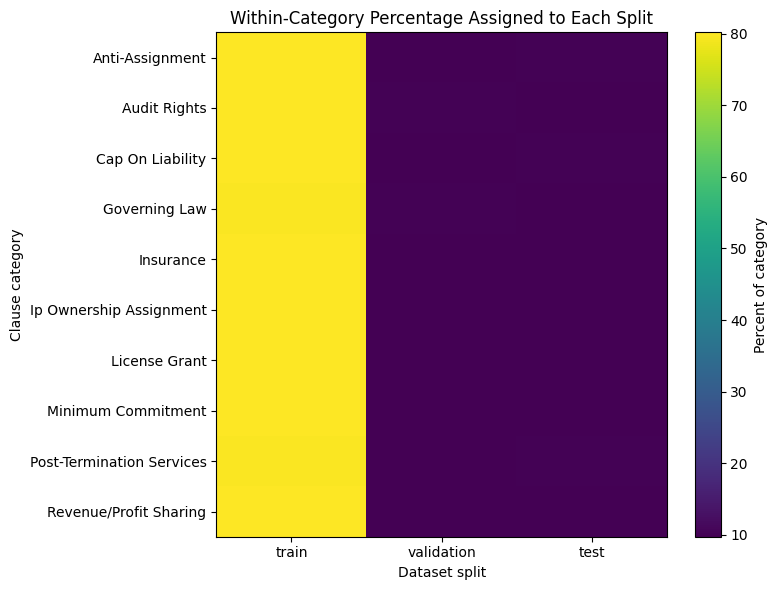

Unique contracts by split:


,contracts
split,
train,368
validation,48
test,46


In [18]:
split_order = ["train", "validation", "test"]
class_split_counts = pd.crosstab(df["category"], df["split"])[split_order]
class_split_pct = class_split_counts.div(class_split_counts.sum(axis=1), axis=0) * 100

display(class_split_counts)
display(class_split_pct.style.format("{:.1f}%"))

fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(class_split_pct.values, aspect="auto")
ax.set_xticks(range(len(split_order)))
ax.set_xticklabels(split_order)
ax.set_yticks(range(len(class_split_pct.index)))
ax.set_yticklabels(class_split_pct.index)
ax.set_title("Within-Category Percentage Assigned to Each Split")
ax.set_xlabel("Dataset split")
ax.set_ylabel("Clause category")
fig.colorbar(image, ax=ax, label="Percent of category")
plt.tight_layout()
plt.show()

print("Unique contracts by split:")
display(
    df.groupby("split")["contract_id"]
      .nunique()
      .reindex(split_order)
      .rename("contracts")
      .to_frame()
)

## Phase 5 checkpoint

The CUAD structural audit is complete:

- The official source, DOI, license, and source-file structure are documented.
- The adaptation from clause extraction to single-label clause-theme classification is explicit.
- Cleaning, duplicate removal, conflicting-label removal, category selection, and contract-grouped splitting are reproducible.
- Required fields contain no missing values.
- Example IDs and normalized-text hashes are unique.
- No source contract occurs in more than one split.
- All ten selected categories appear in training, validation, and test data.
- Representative passages and length characteristics have been inspected.

The next phase constructs the training-only tokenizer and vocabulary, creates PyTorch Dataset and DataLoader objects, and implements the baseline Transformer architecture.